# <font color=#0099CC>**Baseline 1: Buy & Hold**</font>

## <font color=#0099CC>**0. INTRODUCCIÓN**</font>

### <font color=#336699>**0.1. Objetivo de este cuaderno**</font>

Modelo simple **Buy & Hold** utilizado como baseline para comparar con los modelos. La competición se evalúa sobre **log-retornos diarios** (no precios), así que en esta escala la traducción de "comprar y mantener" es: *si los precios no cambian, el log-retorno medio futuro es cero*. La predicción del baseline es por tanto **cero** para los 23 activos. Sin parámetros, sin entrenamiento.

Trabaja sobre **log-retornos diarios** — el MAE se reporta en esa escala (≈ 1e-2).

**Salidas generadas**:
- `08_results/tablas/baseline_buy_and_hold_resultados.csv`
- `08_results/matrices/heatmap_baseline_buy_and_hold_*.png`

## <font color=#0099CC>**1. ENTORNO DE EJECUCIÓN**</font>

### <font color=#336699>**1.1. Detección Colab / local y rutas del proyecto**</font>

Se configura `BASE`, el acceso a Drive cuando aplica y el `sys.path` para importar utilidades compartidas sin duplicar código.

In [1]:
import os, sys

def detect_env():
    try:
        import google.colab
        return 'colab'
    except ImportError:
        return 'local'

ENV = detect_env()

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Taller4_DL_MIAX'
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))

SRC = os.path.join(BASE, '01_src_compartido')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

print(f'> Entorno : {ENV}')
print(f'> BASE    : {BASE}')
print(f'> SRC     : {SRC}')

> Entorno : local
> BASE    : c:\Users\Javi\Desktop\MIAX\Entregas\Entrega 11 - Redes Neuronales\Taller4_DL_MIAX\Taller4_DL_MIAX
> SRC     : c:\Users\Javi\Desktop\MIAX\Entregas\Entrega 11 - Redes Neuronales\Taller4_DL_MIAX\Taller4_DL_MIAX\01_src_compartido


## <font color=#0099CC>**2. IMPORTACIONES**</font>

### <font color=#336699>**2.1. Librerías y módulos compartidos**</font>

Stack numérico mínimo más las utilidades de datos y métricas; se inyecta `BASE` en `metrics_utils` antes de cualquier guardado.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from IPython.display import clear_output

from dataset_utils import load_data, create_dataset, get_partitions
import metrics_utils
metrics_utils.BASE_DRIVE = BASE
from metrics_utils import plot_heatmap, guardar_resultados

## <font color=#0099CC>**3. DESCARGA DE DATOS**</font>

### <font color=#336699>**3.1. Log-retornos diarios de los 23 activos**</font>

`load_data()` con su default `use_log_returns=True` devuelve la matriz `(T, 23)` de **log-retornos diarios** (`np.log(close).diff().dropna()`), que es la escala oficial de la competición.

In [3]:
data, df = load_data()
print(f'> Datos : {data.shape[0]:,} días × {data.shape[1]} activos')
print(f'> Rango : {df.index[0].date()} → {df.index[-1].date()}')

> Datos : 16,197 días × 23 activos
> Rango : 1962-01-03 → 2026-05-12


## <font color=#0099CC>**4. PREDICTOR BUY & HOLD**</font>

### <font color=#336699>**4.1. Predicción cero (los precios no cambian)**</font>

Sobre log-retornos, la estrategia *buy & hold* (mantener la posición) equivale a asumir que el precio no varía: el log-retorno medio futuro es **cero** para los 23 activos. La predicción tiene por tanto forma `(N, 23)` rellena de ceros — *cero parámetros entrenables*.

In [4]:
def predict_buy_and_hold(X):
    """
    X: (N, v_in, Ch) → Y_pred: (N, Ch)
    Buy & Hold sobre log-retornos: si los precios no cambian, el
    log-retorno medio futuro es 0 → la predicción son todos ceros.
    """
    return np.zeros((X.shape[0], X.shape[2]), dtype=X.dtype)

## <font color=#0099CC>**5. EVALUACIÓN 4×4**</font>

### <font color=#336699>**5.1. Combinaciones de ventanas de entrada y salida**</font>

Bucle sobre la rejilla con la partición aleatoria 90/10 (semilla=42): MAE en train, val y test.

In [5]:
ventanas_entrada = [5, 10, 30, 90]
ventanas_salida  = [1, 5, 30, 90]
combos     = list(product(ventanas_entrada, ventanas_salida))
resultados = []

N, BAR_LEN = len(combos), 30

for k, (v_in, v_out) in enumerate(combos, 1):
    filled = int(BAR_LEN * k / N)
    bar    = '█' * filled + '░' * (BAR_LEN - filled)
    clear_output(wait=True)
    print(f'> Evaluación 4x4  [{bar}]  {k:>2}/{N}  '
          f'(V_in={v_in:>2}, V_out={v_out:>2})')

    X, Y = create_dataset(data, v_in, v_out)
    X_tr, X_val, X_test, Y_tr, Y_val, Y_test = get_partitions(X, Y)

    mae_train = float(np.mean(np.abs(predict_buy_and_hold(X_tr)   - Y_tr)))
    mae_val   = float(np.mean(np.abs(predict_buy_and_hold(X_val)  - Y_val)))
    mae_test  = float(np.mean(np.abs(predict_buy_and_hold(X_test) - Y_test)))

    resultados.append({
        'modelo':   'buy_and_hold',
        'v_in':     v_in,
        'v_out':    v_out,
        'n_params': 0,
        'mae_train': mae_train,
        'mae_val':   mae_val,
        'mae_test':  mae_test,
    })

clear_output(wait=True)
print(f'> Evaluación 4x4 completada  [{"█" * BAR_LEN}]  {N}/{N}')
pd.DataFrame(resultados).round(4)

> Evaluación 4x4 completada  [██████████████████████████████]  16/16


,modelo,v_in,v_out,n_params,mae_train,mae_val,mae_test
0,buy_and_hold,5,1,0,0.0116,0.0117,0.0117
1,buy_and_hold,5,5,0,0.0054,0.0054,0.0055
2,buy_and_hold,5,30,0,0.0022,0.0022,0.0022
3,buy_and_hold,5,90,0,0.0013,0.0013,0.0013
4,buy_and_hold,10,1,0,0.0116,0.0117,0.0116
5,buy_and_hold,10,5,0,0.0054,0.0055,0.0054
6,buy_and_hold,10,30,0,0.0022,0.0023,0.0022
7,buy_and_hold,10,90,0,0.0013,0.0013,0.0013
8,buy_and_hold,30,1,0,0.0116,0.0115,0.0116
9,buy_and_hold,30,5,0,0.0054,0.0053,0.0054


## <font color=#0099CC>**6. PERSISTENCIA DE RESULTADOS**</font>

### <font color=#336699>**6.1. Exportación CSV estándar**</font>

CSV con columnas `modelo`, `v_in`, `v_out`, `n_params`, `mae_train`, `mae_val`, `mae_test` — mismo esquema que el resto de modelos.

In [6]:
df_resultados = guardar_resultados(resultados, 'baseline_buy_and_hold')
print('> Resultados guardados : 08_results/tablas/baseline_buy_and_hold_resultados.csv')

> Resultados guardados : 08_results/tablas/baseline_buy_and_hold_resultados.csv


## <font color=#0099CC>**7. MAPAS DE CALOR (MAE)**</font>

### <font color=#336699>**7.1. Heatmaps por partición**</font>

Matrices 4×4 para train, val y test.

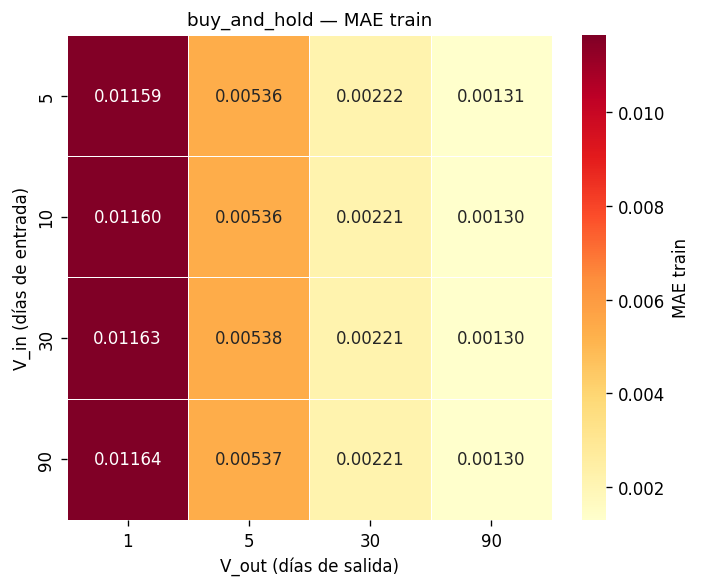

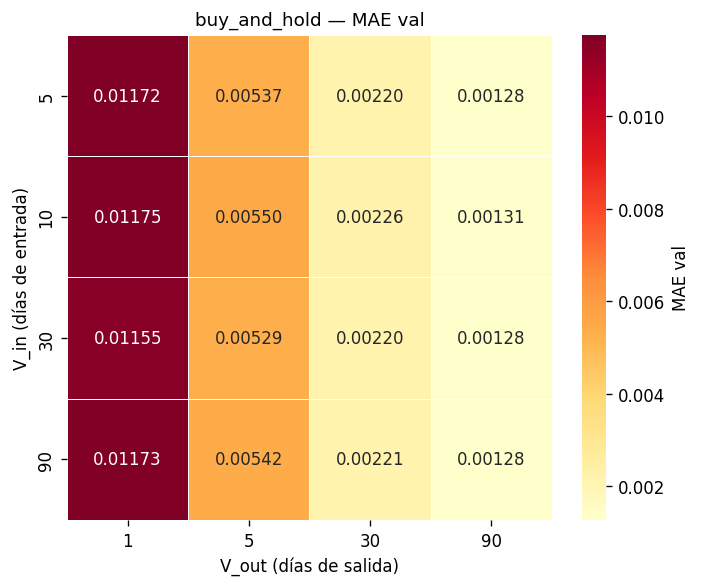

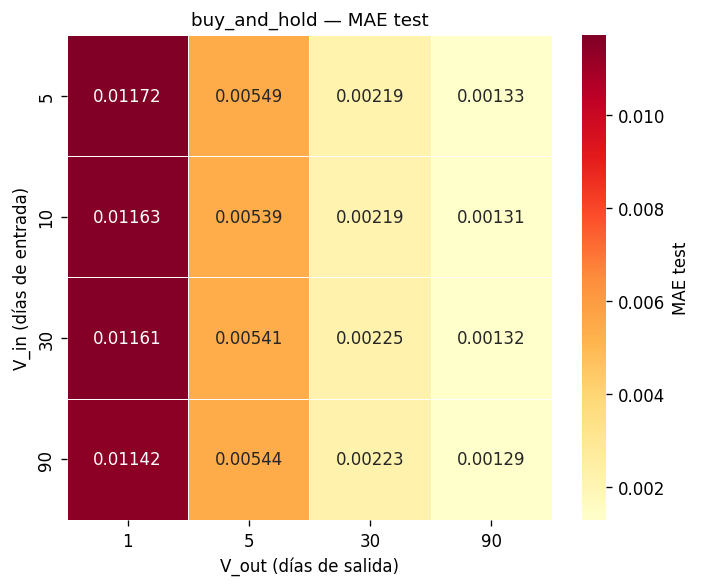

In [7]:
for split in ['train', 'val', 'test']:
    plot_heatmap(df_resultados, 'buy_and_hold', split=split, save=True)
    plt.show()

heatmap_df = pd.concat(
    {split: df_resultados.pivot(index='v_in', columns='v_out',
                                values=f'mae_{split}')
     for split in ['train', 'val', 'test']},
    axis=1,
).round(4)
heatmap_df.index.name = 'V_in \\ V_out'
heatmap_df.style.background_gradient(cmap='YlOrRd', axis=None).format('{:.4f}')

## <font color=#0099CC>**8. TABLA RESUMEN**</font>

### <font color=#336699>**8.1. MAE en test — referencia cruzada**</font>

Vista pivot del MAE en test (escala log-retornos diarios).

In [8]:
print('> MAE TEST: Baseline Buy & Hold (escala log-retornos)')
pivot = (df_resultados
         .pivot(index='v_in', columns='v_out', values='mae_test')
         .round(4))
pivot.index.name   = 'V_in \\ V_out'
pivot.columns.name = None
pivot

> MAE TEST: Baseline Buy & Hold (escala log-retornos)


,1,5,30,90
V_in \ V_out,,,,
5,0.0117,0.0055,0.0022,0.0013
10,0.0116,0.0054,0.0022,0.0013
30,0.0116,0.0054,0.0022,0.0013
90,0.0114,0.0054,0.0022,0.0013
